In [84]:
# Mạng nơ-ron nhân tạo (ANN) dựa trên một tập hợp các đơn vị hoặc nút được kết nối với nhau gọi là nơ-ron nhân tạo, mô hình hóa lỏng lẻo các nơ-ron trong não sinh học. 
# Mỗi kết nối, giống như các khớp thần kinh trong não sinh học, có thể truyền tín hiệu đến các nơ-ron khác. 
# Một nơ-ron nhân tạo nhận được tín hiệu sau đó xử lý nó và có thể gửi tín hiệu đến các nơ-ron được kết nối với nó.

In [85]:
# Để xây dựng và đánh giá một mô hình trong Học sâu, dữ liệu sẵn có thường được chia thành ba tập: tập huấn luyện, tập xác thực và tập kiểm thử.
# Tập huấn luyện được sử dụng để thuật toán học tìm ra các tham số tối ưu cho mô hình.
# Giả sử xảy ra hiện tượng quá khớp (overfitting), ta sẽ điều chỉnh giá trị của một số siêu tham số (hyperparameter). Sau khi huấn luyện lại mô hình với tập huấn luyện, ta sẽ đánh giá lại mô hình bằng tập xác thực. Quá trình điều chỉnh siêu tham số này được lặp lại cho đến khi đạt được kết quả tốt nhất.
# Tập xác thực đã ảnh hưởng đến mô hình khiến mô hình cũng phù hợp với chính tập xác thực này. Vì vậy, ta luôn dành riêng một tập kiểm thử để đánh giá cuối cùng cho mô hình. Tập kiểm thử chỉ được sử dụng một lần, ở giai đoạn cuối cùng khi mô hình đã được tinh chỉnh và ta không còn điều chỉnh thêm bất kỳ siêu tham số nào nữa.

In [86]:
# MNIST là một tập hợp các chữ số viết tay từ 0 đến 9.
# Nó có một tập huấn luyện gồm 60.000 hình ảnh và một tập kiểm tra gồm 10.000 hình ảnh, mỗi hình ảnh được phân vào một lớp (hoặc nhãn) tương ứng.
# Trong thư viện Keras, tập dữ liệu MNIST được tải sẵn dưới dạng bốn mảng NumPy.
# Để sử dụng tập dữ liệu MNIST trong Keras, có một API giúp tải xuống và trích xuất hình ảnh và nhãn một cách tự động.

In [87]:
# Tập dữ liệu Fashion MNIST là một bộ sưu tập gồm 60.000 mẫu hình ảnh để huấn luyện và 10.000 mẫu hình ảnh để kiểm tra. 
# Mỗi hình ảnh có kích thước 28x28 pixel và đại diện cho một trong 10 loại quần áo khác nhau như giày, bốt, áo sơ mi, túi xách, v.v. 
# Chúng ta sẽ xem một số ví dụ ngay sau đây, nhưng trước tiên, chúng ta cần có dữ liệu thực tế. 
# Vì tập dữ liệu gốc bao gồm các tệp nhị phân chứa dữ liệu hình ảnh được mã hóa theo một định dạng cụ thể, nên trong cuốn sách này, chúng tôi đã chuẩn bị và cung cấp một tập dữ liệu đã được xử lý trước, bao gồm các hình ảnh định dạng .png. 
# Thông thường, nên sử dụng nén không mất dữ liệu cho hình ảnh vì nén mất dữ liệu như JPEG sẽ làm ảnh hưởng đến hình ảnh bằng cách thay đổi dữ liệu của chúng. 
# Các hình ảnh này cũng được nhóm theo nhãn và phân chia thành các nhóm huấn luyện và kiểm tra. 
# Mỗi mẫu hình ảnh là một loại quần áo, và nhãn tương ứng với loại quần áo đó.
# Dưới đây là các nhãn số và mô tả tương ứng của chúng:

In [88]:
# 0: Áo phông/áo ba lỗ
# 1: Quần dài
# 2: Áo len chui đầu
# 3: Váy
# 4: Áo khoác
# 5: Dép xỏ ngón
# 6: Áo sơ mi
# 7: Giày thể thao
# 8: Túi xách
# 9: Bốt ngắn

In [89]:
#Code tải dữ liệu về
from zipfile36 import ZipFile
import os
import urllib
import urllib.request

URL = 'https://nnfs.io/datasets/fashion_mnist_images.zip'
FILE = 'fashion_mnist_images.zip'
FOLDER = 'fashion_mnist_images'


if not os.path.isfile(FILE):
   print(f'Downloading {URL} and saving as {FILE}...')
   urllib.request.urlretrieve(URL, FILE)
print('Unzipping images...')
with ZipFile(FILE) as zip_images:
  zip_images.extractall(FOLDER)

print('Done!')

Unzipping images...
Done!


In [199]:
# Bây giờ bạn sẽ có một thư mục tên là fashion_mnist_images, chứa các thư mục test và train cùng với giấy phép sử dụng dữ liệu.
# Trong cả hai thư mục test và train, có 10 thư mục con được đánh số từ 0 đến 9.
# Những số này là các phân loại tương ứng với các hình ảnh bên trong.

# Thường thì người ta chuyển đổi hình ảnh sang thang độ xám (tức là từ mỗi điểm ảnh có 3 kênh màu RGB sang một giá trị duy nhất từ 0 đến 255 biểu thị mức độ sáng tối) mặc dù các hình ảnh trong tập dữ liệu này đã được chuyển đổi sang thang độ xám sẵn rồi.
# Ngoài ra, người ta thường thay đổi kích thước hình ảnh để chuẩn hóa kích thước của chúng, nhưng một lần nữa, tập dữ liệu Fashion MNIST đã được chuẩn bị sẵn sao cho tất cả các hình ảnh đều có cùng kích thước (28x28)."

In [200]:
# Tải dữ liệu lên
import os
labels = os.listdir('fashion_mnist_images/train')
print(labels)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [201]:
# Vì tên của các thư mục con chính là các nhãn, chúng ta có thể tham khảo từng mẫu cho mỗi lớp bằng cách duyệt qua các tệp trong mỗi thư mục con được đánh số.

files = os.listdir('fashion_mnist_images/train/0')
print(files[:10])
print(len(files))

['0000.png', '0001.png', '0002.png', '0003.png', '0004.png', '0005.png', '0006.png', '0007.png', '0008.png', '0009.png']
6000


In [202]:
# Như anh em thấy, chúng ta có 6.000 mẫu hình ảnh thuộc lớp 0. Tổng cộng, chúng ta có 60.000 mẫu hình ảnh, tức là mỗi lớp có 6.000 mẫu.
# Điều này có nghĩa là tập dữ liệu của chúng ta đã được cân bằng, nghĩa là mỗi lớp xuất hiện với tần suất như nhau.
# Nếu tập dữ liệu không được cân bằng, mạng thần kinh có thể thiên về việc dự đoán lớp có nhiều hình ảnh nhất. 
# Điều này là do mạng thần kinh luôn tìm kiếm cách giảm thiểu lỗi nhanh nhất, có thể dẫn đến một cực tiểu cục bộ, khiến mô hình không tìm được giá trị tối ưu toàn cục.
# Với một tập dữ liệu cân bằng, nếu dự đoán ngẫu nhiên, độ chính xác sẽ chỉ khoảng 10%.

# Hãy tưởng tượng nếu sự phân bố các lớp trong tập dữ liệu là 64% cho lớp 0 và 4% cho các lớp còn lại (từ 1 đến 9).
# Mạng thần kinh có thể rất nhanh chóng học được cách luôn dự đoán lớp 0.
# Mặc dù lỗi sẽ giảm nhanh ban đầu, nhưng mô hình có thể sẽ bị mắc kẹt ở việc dự đoán lớp 0 với độ chính xác khoảng 64%.
# Trong trường hợp này, cách tốt hơn là loại bỏ một số mẫu hình ảnh từ các lớp có tần suất cao để các lớp có số lượng mẫu bằng nhau.

In [203]:
# Một cách khác là sử dụng trọng số cho các lớp, tăng trọng số cho các lớp có tần suất thấp hơn. 
# Tuy nhiên, cách này chưa được chứng minh là hiệu quả trong thực tế.
# Với dữ liệu hình ảnh, một lựa chọn khác là tăng cường dữ liệu bằng cách thực hiện các phép biến đổi như cắt xén, xoay, hoặc lật hình ảnh.
# Tuy nhiên, trước khi áp dụng các phép biến đổi này, cần đảm bảo rằng chúng tạo ra các mẫu hình ảnh hợp lệ và phù hợp với mục tiêu của bạn.
# May mắn thay, trong tập dữ liệu Fashion MNIST, các lớp đã được cân bằng hoàn hảo nên chúng ta không cần phải lo lắng về vấn đề này.
# Bây giờ chúng ta sẽ khám phá dữ liệu bằng cách xem xét từng mẫu hình ảnh.
# Để xử lý dữ liệu hình ảnh, chúng ta sẽ sử dụng thư viện OpenCV (cv2) của Python.

import cv2
image_data = cv2.imread('fashion_mnist_images/train/7/0002.png',

cv2.IMREAD_UNCHANGED)

print(image_data)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0  49 135 182 150  59   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  78 255 220 21

In [204]:
# Chúng ta đọc hình ảnh bằng hàm cv2.imread(), trong đó tham số đầu tiên là đường dẫn đến hình ảnh.
# Tham số cv2.IMREAD_UNCHANGED thông báo cho thư viện OpenCV rằng chúng ta muốn đọc hình ảnh theo đúng định dạng mà nó được lưu (trong trường hợp này là thang độ xám).
# Mặc định, OpenCV sẽ chuyển đổi các hình ảnh này để sử dụng tất cả 3 kênh màu, ngay cả khi đó là hình ảnh thang độ xám.
# Kết quả là, chúng ta có một mảng 2 chiều chứa các số - biểu thị giá trị mức xám của từng điểm ảnh.
# Nếu chúng ta định dạng mảng này theo cách khác trước khi in bằng dòng code sau, nó sẽ thông báo cho NumPy (vì hình ảnh đã tải là một đối tượng mảng NumPy) để in nhiều ký tự hơn trên một dòng.

import numpy as np
np.set_printoptions(linewidth=200)

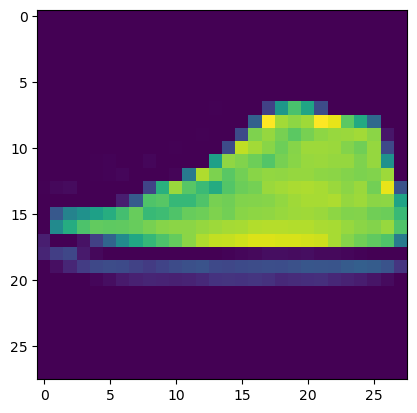

In [205]:
# Trong trường hợp này, đó là một đôi giày thể thao. Thay vì định dạng các giá trị thô để xem chúng theo cách này, chúng ta có thể sử dụng Matplotlib để trực quan hóa. 
# Ví dụ:

import matplotlib.pyplot as plt
plt.imshow(image_data)
plt.show()

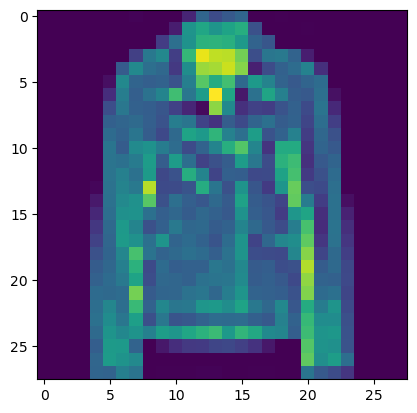

In [206]:
# Với ví dụ khác:
import matplotlib.pyplot as plt
image_data = cv2.imread('fashion_mnist_images/train/4/0011.png',
cv2.IMREAD_UNCHANGED)

plt.imshow(image_data)
plt.show()

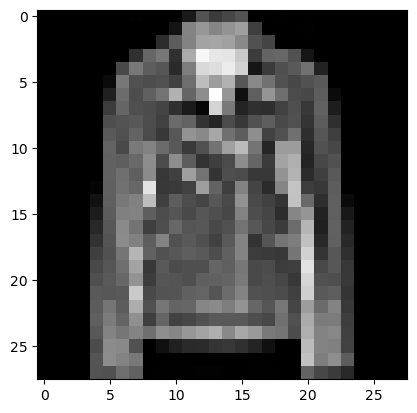

In [207]:
# Hình ảnh này trông giống như một chiếc áo khoác. Nếu chúng ta kiểm tra bảng phân loại trước đó, lớp 4 tương ứng với "áo khoác".
# Ta có thể chuyển ảnh sang thang độ xám

import matplotlib.pyplot as plt
image_data = cv2.imread('fashion_mnist_images/train/4/0011.png', cv2.IMREAD_UNCHANGED)

plt.imshow(image_data, cmap='gray')
plt.show()

In [208]:
# Chúng ta cần thực hiện thao tác này trên cả dữ liệu huấn luyện và dữ liệu kiểm thử. Một lần nữa, chúng đã được chia tách gọn gàng cho chúng ta.
# Nhiều lần, bạn sẽ cần tự mình tách dữ liệu thành các nhóm huấn luyện và kiểm thử.
# Chúng ta sẽ chuyển đổi đoạn mã trên thành một hàm để ngăn chặn việc nhân đôi mã cho các thư mục huấn luyện và kiểm thử.
# Hàm này sẽ nhận một kiểu dữ liệu làm tham số: huấn luyện hoặc kiểm thử, cùng với đường dẫn đến nơi các bộ dữ liệu đó được đặt.

In [209]:
# Vì X đã được định nghĩa là một danh sách, và chúng ta đang thêm các hình ảnh được biểu diễn dưới dạng các mảng NumPy vào danh sách này, chúng ta sẽ gọi np.array() trên X ở cuối để chuyển đổi nó từ một danh sách thành một mảng NumPy đúng.
# Chúng ta sẽ làm tương tự với các nhãn (y) vì chúng là một danh sách các số và bổ sung thông tin cho NumPy rằng các nhãn của chúng là số nguyên (không phải số thực)
# Sau đó, chúng ta có thể viết một hàm để tạo và trả về dữ liệu huấn luyện và kiểm thử của chúng ta.

In [210]:
# Chúng ta sẽ chuẩn hóa dữ liệu (không phải hình ảnh, mà là các con số đại diện cho hình ảnh
# Mạng neural thường hoạt động tốt nhất với dữ liệu nằm trong khoảng từ 0 đến 1 hoặc -1 đến 1. 
# Ở đây, dữ liệu hình ảnh của chúng ta nằm trong khoảng từ 0 đến 255.
# Chúng ta cần quyết định cách để chuẩn hóa dữ liệu này. Thông thường, quá trình này đòi hỏi thử nghiệm và sai sót.
# Ví dụ, chúng ta có thể chuẩn hóa hình ảnh về khoảng từ -1 đến 1 bằng cách lấy giá trị pixel, trừ đi một nửa giá trị pixel lớn nhất (tức là 255/2 = 127.5), sau đó chia cho cùng một giá trị này để thu được khoảng từ -1 đến 1.
# Chúng ta cũng có thể chuẩn hóa dữ liệu về khoảng từ 0 đến 1 bằng cách đơn giản chia nó cho 255 (giá trị lớn nhất).
# Để bắt đầu, chúng ta chọn cách chuẩn hóa về khoảng từ -1 đến 1.
# Trước khi làm điều đó, chúng ta cần thay đổi kiểu dữ liệu của mảng NumPy, hiện tại là uint8 (số nguyên không dấu, chứa các giá trị nguyên trong khoảng từ 0 đến 255).
# nếu không làm điều này, NumPy sẽ chuyển đổi nó thành kiểu dữ liệu float64 trong khi ý định của chúng ta là sử dụng float32, một kiểu số thực 32-bit.
# Điều này có thể đạt được bằng cách gọi .astype(np.float32) trên một đối tượng mảng NumPy. Chúng ta sẽ giữ nguyên các nhãn.

In [211]:
# Đảm bảo rằng bạn chuẩn hóa cả dữ liệu huấn luyện và dữ liệu kiểm thử bằng cùng một phương pháp.
# Sau này, khi thực hiện dự đoán, bạn cũng cần chuẩn hóa dữ liệu đầu vào cho quá trình suy luận.
# Thật dễ dàng để quên chuẩn hóa dữ liệu của bạn ở những vị trí khác nhau.
# Bạn cũng nên đảm bảo rằng bất kỳ quá trình tiền xử lý nào, chẳng hạn như chuẩn hóa, chỉ được thực hiện dựa trên tập dữ liệu huấn luyện của bạn.
# Trong ví dụ này, chúng ta biết giá trị tối thiểu (min) và tối đa (max) sẽ là 0 và 255, và đã thực hiện chuẩn hóa tuyến tính.
# Bạn thường sẽ cần truy vấn trước tập dữ liệu của mình để tìm giá trị min và max để sử dụng trong quá trình chuẩn hóa.
# Bạn cũng có thể sử dụng các phương pháp khác để chuẩn hóa nếu tập dữ liệu của bạn có các giá trị ngoại lệ cực đoan, vì phương pháp min/max có thể không hoạt động tốt.
# Trong trường hợp này, bạn có thể sử dụng một số kết hợp của giá trị trung bình và độ lệch chuẩn để tạo ra phương pháp chuẩn hóa của mình.


# Một sai lầm phổ biến khi chuẩn hóa dữ liệu là để cho tập dữ liệu kiểm thử ảnh hưởng đến các phép biến đổi thực hiện trên tập dữ liệu huấn luyện.
# Chỉ có một ngoại lệ duy nhất cho quy tắc này, đó là khi dữ liệu được chuẩn hóa tuyến tính, ví dụ như chia cho một hằng số.
# Bất kỳ phép biến đổi phi tuyến tính nào cũng có thể dẫn đến rò rỉ thông tin từ tập dữ liệu kiểm tra hoặc xác thực vào tập dữ liệu huấn luyện.
# Bất kỳ quy tắc tiền xử lý nào cũng nên được xác định mà không cần biết đến tập dữ liệu kiểm tra.
# Ví dụ, toàn bộ tập dữ liệu của bạn có thể có giá trị nhỏ nhất là 0 và giá trị lớn nhất là 125, trong khi tập dữ liệu huấn luyện chỉ có giá trị nhỏ nhất là 0 và lớn nhất là 100.
# Bạn vẫn sẽ sử dụng giá trị 100 khi chuẩn hóa tập dữ liệu kiểm tra. Điều này có nghĩa là tập dữ liệu kiểm tra của bạn có thể không nằm gọn trong khoảng từ -1 đến 1 sau khi chuẩn hóa, nhưng điều này thường không phải là vấn đề.
# Trong trường hợp chênh lệch lớn hơn, bạn có thể chuẩn hóa thêm dữ liệu tuyến tính bằng cách chia chúng cho một số nào đó.

In [212]:
# Các lớp Dense (lớp mạng thần kinh đầy đủ) của chúng ta hoạt động trên các batch (nhóm) vector một chiều.
# Chúng không thể xử lý trực tiếp các hình ảnh có dạng mảng hai chiều 28x28.
# Chúng ta cần phải "làm phẳng" (flatten) những hình ảnh này, nghĩa là lấy từng hàng của mảng hình ảnh và nối chúng thành một hàng duy nhất, biến mảng hai chiều (2D) của hình ảnh thành một vector một chiều (1D).
# Nói cách khác, chúng ta có thể hình dung như đang "mở" một mảng 2D ra thành một danh sách.
# Có một loại mạng thần kinh gọi là mạng convolutional (mạng tích chập) có thể xử lý trực tiếp dữ liệu hình ảnh 2D, nhưng các lớp Dense như chúng ta đang sử dụng ở đây lại yêu cầu dữ liệu đầu vào là các vector 1D.
# Thậm chí trong các mạng convolutional, bạn thường vẫn cần làm phẳng dữ liệu trước khi đưa vào lớp output hoặc các lớp Dense khác.
# Để làm phẳng một mảng trong NumPy, chúng ta có thể sử dụng hàm reshape với tham số đầu tiên là -1.
# Điều này có nghĩa là "bất kỳ số lượng phần tử nào có sẵn" và hiệu quả là đưa tất cả các phần tử vào chiều đầu tiên, tạo ra một vector 1D.


# Chúng ta cũng có thể sử dụng np.flatten() nhưng mục đích của chúng ta hơi khác khi làm việc với một batch các mẫu.
# rong trường hợp của các mẫu của chúng ta, chúng ta vẫn muốn giữ lại tất cả 60.000 mẫu, vì vậy chúng ta sẽ reshape dữ liệu huấn luyện của mình thành (60000, -1)
# Điều này thông báo cho NumPy rằng chúng ta muốn giữ nguyên 60.000 mẫu (chiều đầu tiên) nhưng làm phẳng phần còn lại (-1 ở chiều thứ hai có nghĩa là chúng ta muốn đặt tất cả dữ liệu mẫu trong chiều duy nhất này thành một mảng 1D).
# Điều này sẽ tạo ra 60.000 mẫu, mỗi mẫu có 784 đặc trưng. 784 đặc trưng này là kết quả của phép nhân 28x28.
# Để làm điều này, chúng ta sẽ sử dụng số lượng mẫu từ tập huấn luyện (X.shape[0]) và tập kiểm tra (X_test.shape[0]) tương ứng và reshape chúng.

In [213]:
# Bộ dữ liệu của chúng tôi hiện bao gồm các mẫu và phân loại mục tiêu tương ứng của chúng, được sắp xếp theo thứ tự từ 0 đến 9.

# Đây là một vấn đề nếu chúng ta huấn luyện mô hình của mình với dữ liệu theo thứ tự này; vì lý do tương tự, một tập dữ liệu không cân bằng cũng gây ra vấn đề.

# Trong khi huấn luyện trên 6000 mẫu đầu tiên, mô hình sẽ học rằng cách nhanh nhất để giảm thiểu lỗi là luôn dự đoán là 0, vì nó sẽ thấy nhiều batch dữ liệu chỉ có lớp 0. 
# Sau đó, từ 6000 đến 12000, lỗi ban đầu sẽ tăng đột biến khi nhãn thay đổi và mô hình sẽ dự đoán, một cách sai, vẫn là nhãn 0, và có khả năng học rằng bây giờ nó cần phải luôn dự đoán lớp 1 (vì đó là tất cả những gì nó thấy trong các batch nhãn mà chúng ta tối ưu hóa).
# Mô hình sẽ lặp đi lặp lại các cực tiểu cục bộ theo nhãn hiện đang được lặp lại qua các batch và rất có thể sẽ không bao giờ tìm thấy một cực tiểu toàn cục.
# Quá trình này sẽ tiếp tục cho đến khi chúng ta xử lý xong tất cả các mẫu, lặp lại bao nhiêu epoch mà chúng ta đã chọn.

# Tốt hơn hết, mỗi lần cập nhật mô hình (fitment), chúng ta nên có nhiều phân loại khác nhau (lý tưởng là mỗi lớp có một vài mẫu) để tránh trường hợp mô hình chỉ tập trung vào một lớp nhất định mà nó đang thường xuyên gặp phải.
# Do đó, chúng ta thường xáo trộn dữ liệu ngẫu nhiên.
# Với dữ liệu huấn luyện trước đây như dữ liệu xoắn ốc, chúng ta không cần xáo trộn vì chúng ta huấn luyện trên toàn bộ tập dữ liệu cùng một lúc chứ không phải từng batch.
# Với tập dữ liệu lớn hơn hiện tại mà chúng ta đang huấn luyện theo từng batch, chúng ta cần xáo trộn dữ liệu vì hiện tại nó đang được sắp xếp theo các chunk 6000 mẫu cho mỗi nhãn.
# Khi xáo trộn, chúng ta cần đảm bảo rằng cả dữ liệu mẫu và nhãn được xáo trộn cùng nhau; nếu không, mô hình sẽ rất bối rối (và trong hầu hết các trường hợp, sẽ cho kết quả sai) vì nhãn sẽ không còn khớp với mẫu nữa
# Do đó, chúng ta không thể đơn giản gọi hàm shuffle() cho cả hai mảng riêng biệt.
# Có nhiều cách để đạt được điều này, nhưng cách chúng ta sẽ làm là thu thập tất cả các "khóa", vốn giống nhau cho cả mẫu và nhãn, rồi xáo trộn chúng.

In [214]:
# Lớp 0 thực sự là “áo sơ mi” và do đó những dữ liệu này trông được xáo trộn đúng cách. 
# Bạn có thể kiểm tra thêm một số theo cách thủ công để đảm bảo dữ liệu của bạn như mong đợi. 
# Nếu mô hình không huấn luyện hoặc có vẻ như hoạt động sai, bạn sẽ muốn kiểm tra lại cách bạn xử lý trước dữ liệu.

In [215]:
# Đến nay, chúng ta đã huấn luyện các mô hình của mình bằng cách đưa toàn bộ tập dữ liệu vào mô hình như một "batch" duy nhất.
# Tập dữ liệu của chúng ta cho đến nay vẫn đủ nhỏ để có thể xử lý toàn bộ cùng một lúc, nhưng các tập dữ liệu thực tế thường có kích thước hàng terabyte hoặc hơn, điều này vượt quá khả năng xử lý của hầu hết các máy tính.

# Một batch là một phần dữ liệu cố định được lấy ra từ tập dữ liệu.
# Khi huấn luyện với các batch, chúng ta lặp qua tập dữ liệu từng phần một, thực hiện lần lượt quá trình truyền xuôi, tính toán loss, truyền ngược và tối ưu hóa.
# Nếu dữ liệu đã được xáo trộn và mỗi batch đủ lớn, đại diện cho toàn bộ tập dữ liệu, thì ta có thể giả định rằng gradient của mỗi batch sẽ là một xấp xỉ tốt cho hướng đi tới cực tiểu toàn cục.
# Nếu batch quá nhỏ, hướng đi của gradient descent có thể dao động quá nhiều giữa các batch, khiến mô hình mất nhiều thời gian để huấn luyện

# Kích thước batch phổ biến thường nằm trong khoảng từ 32 đến 128 mẫu.
# Bạn có thể chọn kích thước nhỏ hơn nếu gặp khó khăn trong việc đưa tất cả dữ liệu vào bộ nhớ, hoặc lớn hơn nếu muốn quá trình huấn luyện diễn ra nhanh hơn, nhưng khoảng này là phổ biến nhất.
# Thông thường, bạn sẽ thấy độ chính xác và loss cải thiện khi tăng kích thước batch từ 2 lên 8 hoặc từ 8 lên 32.
# Tuy nhiên, đến một lúc nào đó, bạn sẽ thấy hiệu quả giảm dần về độ chính xác và loss nếu tiếp tục tăng kích thước batch

# Ngoài ra, huấn luyện với các batch lớn sẽ trở nên chậm hơn so với tốc độ có thể đạt được với các batch nhỏ hơn - giống như ví dụ về dữ liệu xoắn ốc trước đó, cần đến 10.000 epoch để huấn luyện.
# Như thường lệ với mạng neural, việc lựa chọn kích thước batch phù hợp phụ thuộc rất nhiều vào dữ liệu và mô hình cụ thể của bạn.
# Ví dụ, giả sử chúng ta chọn kích thước batch là 128 và quyết định thực hiện 10 epoch.
# Điều này có nghĩa là, trong mỗi epoch, chúng ta sẽ lặp qua toàn bộ dữ liệu, mỗi lần lấy 128 mẫu để huấn luyện mô hình.
# Mỗi batch gồm 128 mẫu này được gọi là một step.

# Chúng ta sử dụng phép chia lấy phần nguyên (//) thay vì phép chia lấy phần thập phân (/) để đảm bảo kết quả là một số nguyên, vì số step không thể là một phân số.
# Đây chính là số lần lặp mà chúng ta sẽ thực hiện trong mỗi epoch.
# Nếu còn sót lại một số mẫu chưa được xử lý, chúng ta có thể thêm chúng vào bằng cách đơn giản là tăng số step lên 1.
# Phép chia số nguyên làm tròn xuống; do đó, nếu còn mẫu nào, chúng tôi sẽ thêm 1 mẫu để tạo thành lô cuối cùng với phần còn lại.

In [216]:
# Chúng tôi đã tải dữ liệu, xác định số lượng epoch và kích thước batch, sau đó tính toán số step.
# Tiếp theo, chúng ta có hai vòng lặp - một vòng lặp bên ngoài lặp qua các epoch và một vòng lặp bên trong lặp qua các step.
# Trong mỗi step của mỗi epoch, chúng ta chọn một phần của dữ liệu huấn luyện.

# Bây giờ, khi đã biết cách huấn luyện mô hình theo từng batch, chúng ta quan tâm đến việc đánh giá loss (sai số) và độ chính xác của mô hình cho từng step và từng epoch.
# Trước đây, chúng ta chỉ tính toán loss cho mỗi lần fit (huấn luyện) toàn bộ dữ liệu, nhưng bây giờ chúng ta sẽ quan tâm đến cả thống kê theo batch và theo epoch.

# Để tính toán loss và độ chính xác trung bình trên toàn bộ mẫu dữ liệu, chúng ta sẽ tích lũy tổng các loss từ tất cả các batch trong mỗi epoch và tính giá trị trung bình ở cuối mỗi epoch.
# Chúng ta sẽ bắt đầu từ phương thức calculate của lớp Loss
# Trước hết là tạo phương thức tính toán đầy đủ trong lớp Loss:

# Tính toán tổn thất dữ liệu và chính quy hóa
# Đã cho đầu ra mô hình và giá trị chân lý cơ bản
def calculate(self, output, y, *, include_regularization=False):
    # Tính toán tổn thất mẫu
    sample_losses = self.forward(output, y)
    
    # Tính tổn thất trung bình
    data_loss = np.mean(sample_losses)
    
    # Thêm tổng tổn thất tích lũy và số lượng mẫu
    self.accumulated_sum += np.sum(sample_losses)
    self.accumulated_count += len(sample_losses)
    
    # Nếu chỉ mất dữ liệu - hãy trả lại
    if not include_regularization:
        return data_loss
    
    # Trả về dữ liệu và tổn thất chính quy
    return data_loss, self.regularization_loss()

In [217]:
# Chúng ta đang lưu trữ tổng và số lượng để có thể tính toán giá trị trung bình tại bất kỳ thời điểm nào.
# Để làm điều đó, chúng ta sẽ thêm một phương thức mới có tên calculate_accumulated vào lớp Loss.

# Tính tích lũy
def calculate_accumulated(self, *, include_regularization=False):
    # Tính tổn thất trung bình
    data_loss = self.accumulated_sum / self.accumulated_count
    
    # Nếu chỉ mất dữ liệu - hãy trả lại
    if not include_regularization:
        return data_loss
    
    # Trả về dữ liệu và tổn thất chính quy
    return data_loss, self.regularization_loss()

In [218]:
# Phương thức này cũng có thể trả về giá trị loss của regularization nếu đặt tham số include_regularization là True.
# Loss của regularization không cần tích lũy vì nó được tính toán dựa trên trạng thái hiện tại của các tham số layer tại thời điểm gọi hàm.
# Chúng ta sẽ sử dụng tính năng này trong quá trình huấn luyện, nhưng không sử dụng khi đánh giá và dự đoán; chúng ta sẽ thảo luận chi tiết hơn về điều này sau.

# Cuối cùng, để reset lại giá trị tổng và số lượng cho một epoch mới, chúng ta sẽ thêm một phương thức cuối cùng:

# Đặt lại các biến cho tổn thất tích lũy
def new_pass(self):
    self.accumulated_sum = 0
    self.accumulated_count = 0

In [219]:
# Bắt đầu thiết lập khởi tạo mạng nơ ron nhân tạo nhé!
nnfs.init()

In [220]:
# Lớp Dense
class Layer_Dense:
    # Khởi tạo lớp
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, weight_regularizer_l2=0,
                 bias_regularizer_l1=0, bias_regularizer_l2=0):
        
        # Khởi tạo trọng số và độ lệch
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))
        
        # Đặt cường độ chính quy
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.bias_regularizer_l2 = bias_regularizer_l2
        
    # Chuyển tiếp
    def forward(self, inputs, training):
        # Ghi nhớ giá trị đầu vào
        self.inputs = inputs
        # Tính toán giá trị đầu ra từ đầu vào, trọng số và độ lệch
        self.output = np.dot(inputs, self.weights) + self.biases
        
    # Đường chuyền ngược
    def backward(self, dvalues):
        # Độ dốc trên tham số
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        
        # Độ dốc trên chính quy
        # Khối lượng l1
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
            
        # Khối lượng l2
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * \
            self.weights
            
        # Độ lệch L1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # Độ lệch L2
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * \
            self.biases
            
        # Chuyển màu trên các giá trị
        self.dinputs = np.dot(dvalues, self.weights.T)

In [221]:
# Dropout
class Layer_Dropout:
    # Init
    def __init__(self, rate):
        # Tỷ lệ lưu trữ, chúng tôi đảo ngược nó, chẳng hạn như khi dropout
        # là 0,1 chúng ta cần tỷ lệ thành công là 0,9
        self.rate = 1 - rate
        
    # Chuyển tiếp
    def forward(self, inputs, training):
        # Lưu giá trị đầu vào
        self.inputs = inputs
        
        
        # Nếu không ở chế độ đào tạo - trả về giá trị
        if not training:
            self.output = inputs.copy()
            return
        # Tạo và lưu mặt nạ tỷ lệ
        self.binary_mask = np.random.binomial(1, self.rate,
                                              size=inputs.shape) / self.rate
        
        # Áp dụng mặt nạ cho giá trị đầu ra
        self.output = inputs * self.binary_mask
        
    # Đường chuyền ngược
    def backward(self, dvalues):
        # Chuyển màu trên các giá trị
        self.dinputs = dvalues * self.binary_mask

In [222]:
# Lớp Input "layer"
class Layer_Input:
    # Chuyển tiếp
    def forward(self, inputs, training):
        self.output = inputs

In [223]:
# Lớp ReLU activation
class Activation_ReLU:
    # Chuyển tiếp
    def forward(self, inputs, training):
        # Ghi nhớ giá trị đầu vào
        self.inputs = inputs
        # Tính giá trị đầu ra từ đầu vào
        self.output = np.maximum(0, inputs)
        
    # Đường chuyền ngược
    def backward(self, dvalues):
        # Vì chúng ta cần sửa đổi biến ban đầu,
        # trước tiên hãy tạo một bản sao của các giá trị
        self.dinputs = dvalues.copy()
        
        # Độ dốc bằng 0 trong đó giá trị đầu vào âm
        self.dinputs[self.inputs <= 0] = 0

        
    # Tính toán dự đoán cho kết quả đầu ra
    def predictions(self, outputs):
        return outputs

In [224]:
# lớp Softmax activation
class Activation_Softmax:
    # Forward pass
    def forward(self, inputs, training):
        # Ghi nhớ giá trị đầu vào
        self.inputs = inputs
        
        # Nhận xác suất không chuẩn hóa
        exp_values = np.exp(inputs - np.max(inputs, axis=1,
                                            keepdims=True))
        
        # Normalize them for each sample
        probabilities = exp_values / np.sum(exp_values, axis=1,
                                            keepdims=True)
        
        self.output = probabilities
        
    # Backward pass
    def backward(self, dvalues):
        # Tạo mảng chưa được khởi tạo
        self.dinputs = np.empty_like(dvalues)
        
        # Liệt kê kết quả đầu ra và độ dốc
        for index, (single_output, single_dvalues) in \
             enumerate(zip(self.output, dvalues)):
            
            # Làm phẳng mảng đầu ra
            single_output = single_output.reshape(-1, 1)
            # Tính ma trận Jacobian của đầu ra và
            jacobian_matrix = np.diagflat(single_output) - \
            np.dot(single_output, single_output.T)
            
            
            # Tính toán độ dốc theo mẫu
            # và thêm nó vào mảng gradient mẫu
            self.dinputs[index] = np.dot(jacobian_matrix,
                                         single_dvalues)
            
    # Tính toán dự đoán cho kết quả đầu ra
    def predictions(self, outputs):
        return np.argmax(outputs, axis=1)

In [225]:
# Sigmoid activation
class Activation_Sigmoid:
    # Chuyển tiếp
    def forward(self, inputs, training):
        # Lưu đầu vào và tính toán/lưu đầu ra
        # của hàm sigmoid
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
        
    # Đường chuyền ngược
    def backward(self, dvalues):
        # Đạo hàm - tính toán từ đầu ra của hàm sigmoid
        self.dinputs = dvalues * (1 - self.output) * self.output
        
    # Tính toán dự đoán cho kết quả đầu ra
    def predictions(self, outputs):
        return (outputs > 0.5) * 1

In [226]:
# Linear activation
class Activation_Linear:
    # Chuyển tiếp
    def forward(self, inputs, training):
        
        # Just remember values
        self.inputs = inputs
        self.output = inputs
        
    # Đường chuyền ngược
    def backward(self, dvalues):
        # đạo hàm là 1, 1 * dvalues ​​= dvalues ​​- quy tắc dây chuyền
        self.dinputs = dvalues.copy()
        
    # Tính toán dự đoán cho kết quả đầu ra
    def predictions(self, outputs):
        return outputs

In [227]:
# SGD optimizer
class Optimizer_SGD:
    # Khởi tạo trình tối ưu hóa - cài đặt cài đặt,
    # tốc độ học tập là 1. được mặc định cho trình tối ưu hóa này
    def __init__(self, learning_rate=1., decay=0., momentum=0.):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum
        
    # Gọi một lần trước khi cập nhật bất kỳ thông số nào
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
            (1. / (1. + self.decay * self.iterations))
            
    # Cập nhật thông số
    def update_params(self, layer):
        # Nếu chúng ta sử dụng động lượng
        if self.momentum:
            # Nếu lớp không chứa mảng động lượng, hãy tạo chúng
            # chứa đầy số không
            if not hasattr(layer, 'weight_momentums'):
                layer.weight_momentums = np.zeros_like(layer.weights)
                
                # Nếu không có mảng động lượng cho tạ
                # Mảng này cũng chưa tồn tại cho các thành kiến.
                layer.bias_momentums = np.zeros_like(layer.biases)
                
            # Xây dựng thông tin cập nhật về cân nặng theo đà - thực hiện trước đó
            # cập nhật nhân với hệ số giữ lại và cập nhật với
            # độ dốc hiện tại
            weight_updates = \
                 self.momentum * layer.weight_momentums - \
                 self.current_learning_rate * layer.dweights
            layer.weight_momentums = weight_updates
            
            
            # Xây dựng các cập nhật thiên vị
            bias_updates = \
                self.momentum * layer.bias_momentums - \
                self.current_learning_rate * layer.dbiases
            layer.bias_momentums = bias_updates
            
            # Cập nhật Vanilla SGD (như trước khi cập nhật đà)
        else:
            weight_updates = -self.current_learning_rate * \
                             layer.dweights
            
            bias_updates = -self.current_learning_rate * \
                           layer.dbiases
            
            
        # Cập nhật trọng số và độ lệch bằng cách sử dụng một trong hai
        # cập nhật vanilla hoặc động lượng
        layer.weights += weight_updates
        layer.biases += bias_updates
        
    # Gọi một lần sau khi cập nhật bất kỳ tham số nào
    def post_update_params(self):
        self.iterations += 1

In [228]:
# Adagrad optimizer
class Optimizer_Adagrad:
    # Khởi tạo trình tối ưu hóa - cài đặt cài đặt
    def __init__(self, learning_rate=1., decay=0., epsilon=1e-7):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        
    # Gọi một lần trước khi cập nhật bất kỳ thông số nào
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                 (1. / (1. + self.decay * self.iterations))
            
    # Cập nhật thông số
    def update_params(self, layer):
        # Nếu lớp không chứa mảng bộ đệm,
        # tạo ra chúng chứa đầy số không
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)
            
        # Cập nhật bộ đệm với độ dốc hiện tại bình phương
        layer.weight_cache += layer.dweights**2
        layer.bias_cache += layer.dbiases**2
        
        # Cập nhật tham số Vanilla SGD + chuẩn hóa
        # với bộ đệm gốc vuông
        layer.weights += -self.current_learning_rate * \
                         layer.dweights / \
                         (np.sqrt(layer.weight_cache) + self.epsilon)
        
        layer.biases += -self.current_learning_rate * \
                        layer.dbiases / \
                        (np.sqrt(layer.bias_cache) + self.epsilon)
        
    # Gọi một lần sau khi cập nhật bất kỳ tham số nào
    def post_update_params(self):
        self.iterations += 1

In [229]:
# RMSprop optimizer
class Optimizer_RMSprop:
    # Khởi tạo trình tối ưu hóa - cài đặt cài đặt
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7,
                 rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho
        
    # Gọi một lần trước khi cập nhật bất kỳ thông số nào
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                 (1. / (1. + self.decay * self.iterations))
            
    # Cập nhật thông số
    def update_params(self, layer):
        # Nếu lớp không chứa mảng bộ đệm,
        # tạo ra chúng chứa đầy số không
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)
            
        # Cập nhật bộ đệm với độ dốc hiện tại bình phương
        layer.weight_cache = self.rho * layer.weight_cache + \
            (1 - self.rho) * layer.dweights**2
        layer.bias_cache = self.rho * layer.bias_cache + \
             (1 - self.rho) * layer.dbiases**2
        
        # Cập nhật tham số Vanilla SGD + chuẩn hóa
        # với bộ đệm gốc vuông
        layer.weights += -self.current_learning_rate * \
                         layer.dweights / \
                         (np.sqrt(layer.weight_cache) + self.epsilon)
        
        layer.biases += -self.current_learning_rate * \
                        layer.dbiases / \
                        (np.sqrt(layer.bias_cache) + self.epsilon)
        
    # Gọi một lần sau khi cập nhật bất kỳ tham số nào
    def post_update_params(self):
        self.iterations += 1

In [230]:
# Adam optimizer
class Optimizer_Adam:
    # Khởi tạo trình tối ưu hóa - cài đặt cài đặt
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7,
                 beta_1=0.9, beta_2=0.999):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1
        self.beta_2 = beta_2
        
    # Gọi một lần trước khi cập nhật bất kỳ thông số nào
    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate * \
                (1. / (1. + self.decay * self.iterations))
            
    # Cập nhật thông số
    def update_params(self, layer):
        # Nếu lớp không chứa mảng bộ đệm,
        # tạo ra chúng chứa đầy số không
        if not hasattr(layer, 'weight_cache'):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)
            
        # Cập nhật đà với độ dốc hiện tại
        layer.weight_momentums = self.beta_1 * \
                                 layer.weight_momentums + \
                                 (1 - self.beta_1) * layer.dweights
        
        layer.bias_momentums = self.beta_1 * \
                               layer.bias_momentums + \
                               (1 - self.beta_1) * layer.dbiases
        
        # Lấy đà điều chỉnh
        # self.iteration = 0 ở lần vượt qua đầu tiên
        # và chúng ta cần bắt đầu = 1 ở đây
        
        weight_momentums_corrected = layer.weight_momentums / \
             (1 - self.beta_1 ** (self.iterations + 1))
        bias_momentums_corrected = layer.bias_momentums / \
             (1 - self.beta_1 ** (self.iterations + 1))
        
        # Cập nhật bộ đệm với độ dốc hiện tại bình phương
        layer.weight_cache = self.beta_2 * layer.weight_cache + \
             (1 - self.beta_2) * layer.dweights**2
        layer.bias_cache = self.beta_2 * layer.bias_cache + \
             (1 - self.beta_2) * layer.dbiases**2
        
        # Nhận bộ đệm đã sửa
        weight_cache_corrected = layer.weight_cache / \
             (1 - self.beta_2 ** (self.iterations + 1))
        bias_cache_corrected = layer.bias_cache / \
             (1 - self.beta_2 ** (self.iterations + 1))
        
        # Cập nhật tham số Vanilla SGD + chuẩn hóa
        # với bộ đệm gốc vuông
        layer.weights += -self.current_learning_rate * \
                         weight_momentums_corrected / \
                        (np.sqrt(weight_cache_corrected) +
                            self.epsilon)
        
        layer.biases += -self.current_learning_rate * \
                        bias_momentums_corrected / \
                        (np.sqrt(bias_cache_corrected) +
                            self.epsilon)
        
    # Gọi một lần sau khi cập nhật bất kỳ tham số nào
    def post_update_params(self):
        self.iterations += 1

In [231]:
# Tạo lớp Loss như sau

class Loss:
    # Tính toán tổn thất chính quy
    def regularization_loss(self):
        
        # Mặc định 0
        regularization_loss = 0
        
        # Tính toán tổn thất chính quy
        # lặp lại tất cả các lớp có thể huấn luyện được
        
        for layer in self.trainable_layers:
            # Chính quy hóa L1 - trọng số
            # chỉ tính khi hệ số lớn hơn 0
            
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * \
                np.sum(np.abs(layer.weights))
                
            # Chính quy hóa L2 - trọng số
            
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * \
                np.sum(layer.weights * \
                       layer.weights)
                
            # Chính quy hóa L1 - độ lệch
            # chỉ tính khi hệ số lớn hơn 0
            
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * \
                np.sum(np.abs(layer.biases))
                
                
            # Chính quy hóa L2 - độ lệch
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * \
                np.sum(layer.biases * \
                       layer.biases)
                
        return regularization_loss
    
    # Đặt/ghi nhớ các lớp có thể huấn luyện được
    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers
        
    # Tính toán tổn thất dữ liệu và chính quy hóa
    # Đã cho đầu ra mô hình và giá trị chân lý cơ bản
    
    def calculate(self, output, y, *, include_regularization=False):
        # Tính toán tổn thất mẫu
        sample_losses = self.forward(output, y)
        
        # Tính tổn thất trung bình
        data_loss = np.mean(sample_losses)
        
        # Thêm tổng tổn thất tích lũy và số lượng mẫu
        self.accumulated_sum += np.sum(sample_losses)
        self.accumulated_count += len(sample_losses)
        
        # Nếu chỉ mất dữ liệu - hãy trả lại
        if not include_regularization:
            return data_loss
        
        # Trả về dữ liệu và tổn thất chính quy
        return data_loss, self.regularization_loss()
    
    # Tính tích lũy
    def calculate_accumulated(self, *, include_regularization=False):
        # Tính tổn thất trung bình
        data_loss = self.accumulated_sum / self.accumulated_count
        
        # Nếu chỉ mất dữ liệu - hãy trả lại
        if not include_regularization:
            return data_loss
        
        # Trả về dữ liệu và tổn thất chính quy
        return data_loss, self.regularization_loss()
    
    # Đặt lại các biến cho tổn thất tích lũy
    def new_pass(self):
        self.accumulated_sum = 0
        self.accumulated_count = 0

In [232]:
# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
    # Chuyển tiếp
    def forward(self, y_pred, y_true):
        # Số lượng mẫu trong một đợt
        samples = len(y_pred)
        
        # Cắt dữ liệu để ngăn chia cho 0
        # Cắt cả hai bên để không kéo ý nghĩa về phía bất kỳ giá trị nào
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        
        # Xác suất cho các giá trị mục tiêu -
        # chỉ khi nhãn phân loại
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
                range(samples),
                y_true
            ]
            
        # Giá trị mặt nạ - chỉ dành cho nhãn được mã hóa một lần
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
                y_pred_clipped * y_true,
                axis=1
            )
        
        # Tổn thất
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    
    # Đường chuyền ngược
    def backward(self, dvalues, y_true):
        # Số lượng mẫu
        samples = len(dvalues)
        # Số lượng nhãn trong mỗi mẫu
        # Chúng tôi sẽ sử dụng mẫu đầu tiên để đếm chúng
        labels = len(dvalues[0])
        # Nếu nhãn thưa thớt, hãy biến chúng thành vectơ một điểm nóng
        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]
        # Tính độ dốc
        self.dinputs = -y_true / dvalues
        # Chuẩn hóa độ dốc
        self.dinputs = self.dinputs / samples

In [233]:
# Trình phân loại Softmax - kích hoạt Softmax kết hợp
# và mất entropy chéo để có bước lùi nhanh hơn
class Activation_Softmax_Loss_CategoricalCrossentropy():
    # Đường chuyền ngược
    def backward(self, dvalues, y_true):
        # Số lượng mẫu
        samples = len(dvalues)
        # Nếu nhãn được mã hóa một lần,
        # biến chúng thành các giá trị rời rạc
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
            
        # Sao chép để chúng tôi có thể sửa đổi một cách an toàn
        self.dinputs = dvalues.copy()
        # Tính độ dốc
        self.dinputs[range(samples), y_true] -= 1
        # Chuẩn hóa độ dốc
        self.dinputs = self.dinputs / samples

In [234]:
# Binary cross-entropy loss
class Loss_BinaryCrossentropy(Loss):
    # Chuyển tiếp
    def forward(self, y_pred, y_true):
        # Cắt dữ liệu để ngăn chia cho 0
        # Cắt cả hai bên để không kéo ý nghĩa về phía bất kỳ giá trị nào
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        # Tính toán tổn thất theo mẫu
        sample_losses = -(y_true * np.log(y_pred_clipped) +
                          (1 - y_true) * np.log(1 - y_pred_clipped))
        sample_losses = np.mean(sample_losses, axis=-1)
        
        # Trả lại tổn thất
        return sample_losses
    
    # Đường chuyền ngược
    def backward(self, dvalues, y_true):
        # Số lượng mẫu
        samples = len(dvalues)
        # Số lượng đầu ra trong mỗi mẫu
        # Chúng tôi sẽ sử dụng mẫu đầu tiên để đếm chúng
        outputs = len(dvalues[0])
        # Cắt dữ liệu để ngăn chia cho 0
        # Cắt cả hai bên để không kéo ý nghĩa về phía bất kỳ giá trị nào
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7)
        
        # Tính độ dốc
        self.dinputs = -(y_true / clipped_dvalues -
                         (1 - y_true) / (1 - clipped_dvalues)) / outputs
        # Chuẩn hóa độ dốc
        self.dinputs = self.dinputs / samples

In [235]:
# Mean Squared Error loss
class Loss_MeanSquaredError(Loss): # Mất mát L2
    # Chuyển tiếp
    def forward(self, y_pred, y_true):
        # Tính toán tổn thất
        sample_losses = np.mean((y_true - y_pred)**2, axis=-1)
        # Trả lại tổn thất
        return sample_losses
    
    # Đường chuyền ngược
    def backward(self, dvalues, y_true):
        # Số lượng mẫu
        samples = len(dvalues)
        # Số lượng đầu ra trong mỗi mẫu
        # Chúng tôi sẽ sử dụng mẫu đầu tiên để đếm chúng
        outputs = len(dvalues[0])
        # Chuyển màu trên các giá trị
        self.dinputs = -2 * (y_true - dvalues) / outputs
        # Chuẩn hóa độ dốc
        self.dinputs = self.dinputs / samples

In [236]:
# Mean Absolute Error loss
class Loss_MeanAbsoluteError(Loss): # Mất mát L1
    def forward(self, y_pred, y_true):
        # Tính toán tổn thất
        sample_losses = np.mean(np.abs(y_true - y_pred), axis=-1)
        # Trả lại tổn thất
        return sample_losses
    
    # Backward pass
    def backward(self, dvalues, y_true):
        # Số lượng mẫu
        samples = len(dvalues)
        # Số lượng đầu ra trong mỗi mẫu
        # Chúng tôi sẽ sử dụng mẫu đầu tiên để đếm chúng
        outputs = len(dvalues[0])
        # Chuyển màu trên các giá trị
        self.dinputs = np.sign(y_true - dvalues) / outputs
        # Chuẩn hóa độ dốc
        self.dinputs = self.dinputs / samples

In [237]:
# Với lớp Accuracy

class Accuracy:
    # Tính toán độ chính xác
    # đưa ra dự đoán và giá trị chân lý cơ bản
    
    def calculate(self, predictions, y):
        # Lấy kết quả so sánh
        comparisons = self.compare(predictions, y)
        
        # Tính toán độ chính xác
        accuracy = np.mean(comparisons)
        
        # Thêm tổng tích lũy của các giá trị phù hợp và số lượng mẫu
        self.accumulated_sum += np.sum(comparisons)
        self.accumulated_count += len(comparisons)
        
        # Trả về độ chính xác
        return accuracy
    
    # Tính toán độ chính xác tích lũy
    def calculate_accumulated(self):
        # Tính toán độ chính xác
        accuracy = self.accumulated_sum / self.accumulated_count
        
        # Trả về dữ liệu và tổn thất chính quy
        return accuracy
    
    # Đặt lại các biến để có độ chính xác tích lũy
    def new_pass(self):
        self.accumulated_sum = 0
        self.accumulated_count = 0

In [238]:
# Tính toán chính xác cho mô hình phân loại
class Accuracy_Categorical(Accuracy):
    # Không cần khởi tạo
    def init(self, y):
        pass
    
    # So sánh dự đoán với giá trị thực tế cơ bản
    def compare(self, predictions, y):
        if len(y.shape) == 2:
            y = np.argmax(y, axis=1)
        return predictions == y

In [239]:
# Tính toán độ chính xác cho mô hình hồi quy
class Accuracy_Regression(Accuracy):
    def __init__(self):
        # Tạo thuộc tính chính xác
        self.precision = None
        
    # Tính giá trị chính xác
    # dựa trên các giá trị thực tế được truyền vào
    def init(self, y, reinit=False):
        if self.precision is None or reinit:
            self.precision = np.std(y) / 250
            
    # So sánh dự đoán với giá trị thực tế cơ bản
    def compare(self, predictions, y):
        return np.absolute(predictions - y) < self.precision

In [240]:
# Lớp Model
class Model:
    def __init__(self):
        # Tạo danh sách các đối tượng mạng
        self.layers = []
        # Đối tượng đầu ra của trình phân loại Softmax
        self.softmax_classifier_output = None
        
    # Thêm đối tượng vào mô hình
    def add(self, layer):
        self.layers.append(layer)
        
    # Đặt mất mát, tối ưu hóa và độ chính xác
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
        
    # Hoàn thiện mô hình
    def finalize(self):
        # Tạo và thiết lập lớp đầu vào
        self.input_layer = Layer_Input()
        # Đếm tất cả đồ vật
        layer_count = len(self.layers)
        # Khởi tạo danh sách chứa các lớp có thể huấn luyện:
        self.trainable_layers = []
        # Lặp lại các đối tượng
        for i in range(layer_count):
            # Nếu là lớp đầu tiên,
            # đối tượng lớp trước là lớp đầu vào
            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
                
            # Tất cả các lớp ngoại trừ lớp đầu tiên và lớp cuối cùng
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
                
            # Lớp cuối cùng - đối tượng tiếp theo là mất mát
            # Ngoài ra, hãy lưu tham chiếu đến đối tượng cuối cùng
            # đầu ra của nó là đầu ra của mô hình
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]
                
            # Nếu lớp chứa một thuộc tính gọi là "trọng lượng",
            # đó là một lớp có thể huấn luyện được -
            # thêm nó vào danh sách các lớp có thể huấn luyện
            # Chúng ta không cần kiểm tra những thành kiến ​​-
            # kiểm tra trọng lượng là đủ
            
            if hasattr(self.layers[i], 'weights'):
                self.trainable_layers.append(self.layers[i])
            # Update loss object with trainable layers
            self.loss.remember_trainable_layers(
                self.trainable_layers
            )
        # Nếu kích hoạt đầu ra là Softmax và
        # hàm mất là Entropy chéo phân loại
        # tạo một đối tượng kích hoạt kết hợp
        # và hàm mất mát chứa
        # tính toán độ dốc nhanh hơn
        if isinstance(self.layers[-1], Activation_Softmax) and \
           isinstance(self.loss, Loss_CategoricalCrossentropy):
            # Create an object of combined activation
            # and loss functions
            self.softmax_classifier_output = \
                Activation_Softmax_Loss_CategoricalCrossentropy()
    # Ở đây, chúng ta đã thêm việc thiết lập các thuộc tính accumulated_sum và accumulated_count vào phương thức calculate để tính toán độ chính xác của một epoch, thêm một phương thức mới là calculate_accumulated để trả về độ chính xác này, và cuối cùng thêm một phương thức new_pass để reset lại các giá trị accumulated_sum và accumulated_count mà chúng ta sẽ sử dụng ở đầu mỗi epoch.
    # Tiếp theo, chúng ta sẽ sửa đổi phương thức train của lớp Model. Đầu tiên, chúng ta sẽ thêm một tham số mới có tên là batch_size.        
    # Huấn luyện mô hình
    def train(self, X, y, *, epochs=1, batch_size=None,
              print_every=1, validation_data=None):
        # Khởi tạo đối tượng chính xác
        self.accuracy.init(y)
        
        # Chúng ta sẽ đặt giá trị mặc định cho tham số này là None, có nghĩa là sử dụng toàn bộ tập dữ liệu làm một batch.
        # Trong trường hợp này, quá trình huấn luyện sẽ chỉ có 1 step cho mỗi epoch, và step đó bao gồm việc đưa toàn bộ dữ liệu qua mạng thần kinh một lần.
        # Giá trị mặc định nếu kích thước lô không được đặt
        train_steps = 1
        
        # Nếu có dữ liệu xác nhận được thông qua,
        # cũng đặt số bước mặc định để xác thực
        if validation_data is not None:
            validation_steps = 1
            # Để dễ đọc hơn
            X_val, y_val = validation_data
            
            # Như đã thảo luận, hầu hết các tập dữ liệu "thực tế" sẽ yêu cầu kích thước batch nhỏ hơn so với tổng số mẫu.
            # Chúng ta sẽ xử lý điều này bằng cách sử dụng phương pháp đã mô tả trước đó: thực hiện phép chia lấy phần nguyên số lượng mẫu cho kích thước batch và cuối cùng cộng thêm 1 để bao gồm bất kỳ mẫu còn lại nào không tạo thành một batch đầy đủ (chúng ta sẽ làm điều này cho cả dữ liệu huấn luyện và dữ liệu validation).
            # Tính số bước
            if batch_size is not None:
                train_steps = len(X) // batch_size
                # Chia vòng xuống. Nếu còn lại một số
                # dữ liệu nhưng không phải là một lô đầy đủ, điều này sẽ không bao gồm nó
                # Thêm `1` để bao gồm lô chưa đầy đủ này
                
                if train_steps * batch_size < len(X):
                    train_steps += 1
                    if validation_data is not None:
                        validation_steps = len(X_val) // batch_size
                        # Chia vòng xuống. Nếu còn lại một số
                        # dữ liệu, nhưng không phải là một lô đầy đủ, điều này sẽ không bao gồm nó
                        # Thêm 1 để bao gồm lô không đầy đủ này
                        
                        if validation_steps * batch_size < len(X_val):
                            validation_steps += 1
                            
            # Vòng đào tạo chính
            for epoch in range(1, epochs+1):
                # Tiếp theo, bắt đầu từ đầu, chúng ta sẽ sửa đổi vòng lặp qua các epoch để in ra số thứ tự của epoch và sau đó reset lại các giá trị tích lũy của loss và độ chính xác cho epoch đó.
                # Sau đó, bên trong vòng lặp này, chúng ta sẽ thêm một vòng lặp mới để lặp qua các step trong mỗi epoch.
                # In số epoch
                print(f'epoch: {epoch}')
                
                # Đặt lại giá trị tích lũy trong các đối tượng mất mát và chính xác
                self.loss.new_pass()
                self.accuracy.new_pass()
                
                # Lặp lại các bước
                for step in range(train_steps):
                    # Bên trong mỗi bước, chúng ta cần lấy một batch dữ liệu để sử dụng cho việc huấn luyện - hoặc là toàn bộ tập dữ liệu nếu tham số batch_size vẫn giữ giá trị mặc định là None, hoặc là một phần của tập dữ liệu có kích thước bằng batch_size.
                    # Nếu kích thước lô không được đặt -
                    # đào tạo bằng cách sử dụng một bước và tập dữ liệu đầy đủ
                    
                    if batch_size is None:
                        batch_X = X
                        batch_y = y
                        
                    # Nếu không thì cắt một mẻ
                    else:
                        batch_X = X[step*batch_size:(step+1)*batch_size]
                        batch_y = y[step*batch_size:(step+1)*batch_size]
                    
                    # Với mỗi batch này, chúng ta sẽ huấn luyện mô hình và in ra thông tin, tương tự như cách chúng ta làm với mỗi epoch.
                    # Điểm khác biệt ở đây là chúng ta sử dụng batch_X thay cho X và batch_y thay cho y. Thay đổi khác là câu lệnh if để in tóm tắt sẽ tính theo số step thay vì số epoch.
                    # Thực hiện chuyển tiếp
                    output = self.forward(batch_X, training=True)
                    
                    # Tính toán tổn thất
                    data_loss, regularization_loss = \
                         self.loss.calculate(output, batch_y,
                                             include_regularization=True)
                    loss = data_loss + regularization_loss
                    
                    # Nhận dự đoán và tính toán độ chính xác
                    predictions = self.output_layer_activation.predictions(
                                       output)
                    
                    accuracy = self.accuracy.calculate(predictions,
                                                       batch_y)
                    
                    # Thực hiện chuyền ngược
                    self.backward(output, batch_y)
                    
                    # Tối ưu hóa (cập nhật thông số)
                    self.optimizer.pre_update_params()
                    for layer in self.trainable_layers:
                        self.optimizer.update_params(layer)
                    self.optimizer.post_update_params()
                    
                    # In bản tóm tắt
                    if not step % print_every or step == train_steps - 1:
                        print(f'step: {step}, ' +
                              f'acc: {accuracy:.3f}, ' +
                              f'loss: {loss:.3f} (' +
                              f'data_loss: {data_loss:.3f}, ' +
                              f'reg_loss: {regularization_loss:.3f}), ' +
                              f'lr: {self.optimizer.current_learning_rate}')
                # Sau đó, chúng tôi muốn in thông tin như độ chính xác và tổn thất trên mỗi epoch:        
                # Nhận và in mất epoch và độ chính xác
                epoch_data_loss, epoch_regularization_loss = \
                    self.loss.calculate_accumulated(
                        include_regularization=True)
                epoch_loss = epoch_data_loss + epoch_regularization_loss
                epoch_accuracy = self.accuracy.calculate_accumulated()
                
                print(f'training, ' +
                      f'acc: {epoch_accuracy:.3f}, ' +
                      f'loss: {epoch_loss:.3f} (' +
                      f'data_loss: {epoch_data_loss:.3f}, ' +
                      f'reg_loss: {epoch_regularization_loss:.3f}), ' +
                      f'lr: {self.optimizer.current_learning_rate}')
                
                # Nếu kích thước lô được đặt, rất có thể dữ liệu xác thực của chúng tôi sẽ lớn hơn kích thước lô này, vì vậy chúng ta cũng cần thêm batching cho dữ liệu xác thực:
                # Nếu có dữ liệu xác nhận
                if validation_data is not None:
                    # Đặt lại giá trị tích lũy bị mất
                    # và các đối tượng chính xác
                    self.loss.new_pass()
                    self.accuracy.new_pass()
                    
                    # Lặp lại các bước
                    for step in range(validation_steps):
                        # Nếu kích thước lô không được đặt -
                        # đào tạo bằng cách sử dụng một bước và tập dữ liệu đầy đủ
                        if batch_size is None:
                            batch_X = X_val
                            batch_y = y_val
                            
                        # Nếu không thì cắt một mẻ
                        else:
                            batch_X = X_val[
                                step*batch_size:(step+1)*batch_size
                            ]
                            batch_y = y_val[
                                step*batch_size:(step+1)*batch_size
                            ]
                        # Thực hiện chuyển tiếp
                        output = self.forward(batch_X, training=False)
                        
                        # Tính toán tổn thất
                        self.loss.calculate(output, batch_y)
                        
                        # Nhận dự đoán và tính toán độ chính xác
                        predictions = self.output_layer_activation.predictions(
                                           output)
                        self.accuracy.calculate(predictions, batch_y)
                        
                    # Nhận và in mất xác thực và độ chính xác
                    validation_loss = self.loss.calculate_accumulated()
                    validation_accuracy = self.accuracy.calculate_accumulated()
                    
                    # In bản tóm tắt
                    print(f'validation, ' +
                          f'acc: {validation_accuracy:.3f}, ' +
                          f'loss: {validation_loss:.3f}')
    # So với codebase hiện tại của chúng ta, chúng ta đã thêm các cuộc gọi đến phương thức new_pass của cả đối tượng loss và accuracy, để reset lại các giá trị tích lũy trong quá trình huấn luyện.
    # Tiếp theo, chúng ta đã giới thiệu khái niệm batch (một vòng lặp lặp qua các step) và loại bỏ việc bắt lấy kết quả trả về từ phép tính loss (vì chúng ta không quan tâm đến loss của từng batch trong quá trình validation, mà chỉ quan tâm đến loss tổng thể cuối cùng).
    # Các bước cuối cùng là thêm phần xử lý cho loss tổng thể của validation và thay thế X_val bằng batch_X và y_val bằng batch_y để phù hợp với những thay đổi đã thực hiện trong code huấn luyện."

    # Thực hiện chuyển tiếp
    def forward(self, X, training):
        # Phương thức chuyển tiếp cuộc gọi trên lớp đầu vào
        # điều này sẽ đặt thuộc tính đầu ra
        # lớp đầu tiên trong đối tượng "prev" đang được mong đợi
        self.input_layer.forward(X, training)
        # Phương thức chuyển tiếp cuộc gọi của mọi đối tượng trong chuỗi
        # Truyền đầu ra của đối tượng trước đó làm tham số
        for layer in self.layers:
            layer.forward(layer.prev.output, training)
        # "lớp" bây giờ là đối tượng cuối cùng trong danh sách,
        # trả lại đầu ra của nó
        return layer.output
    
    # Performs backward pass
    def backward(self, output, y):
        # If softmax classifier
        if self.softmax_classifier_output is not None:
            # Phương thức gọi lùi đầu tiên
            # khi kích hoạt/mất kết hợp
            # điều này sẽ thiết lập thuộc tính dinputs
            self.softmax_classifier_output.backward(output, y)
            # Vì chúng ta sẽ không gọi phương thức lùi của lớp cuối cùng
            # đó là kích hoạt Softmax
            # vì chúng tôi đã sử dụng kết hợp kích hoạt/mất
            # đối tượng, hãy đặt thông số đầu vào trong đối tượng này
            self.layers[-1].dinputs = \
                 self.softmax_classifier_output.dinputs
            
            # Gọi phương thức lùi đi qua
            # tất cả các đối tượng nhưng cuối cùng
            # theo thứ tự đảo ngược chuyển đầu vào dưới dạng tham số
            for layer in reversed(self.layers[:-1]):
                layer.backward(layer.next.dinputs)
            return
        # Đầu tiên gọi phương thức lùi về tổn thất
        # cái này sẽ đặt thuộc tính dinputs cuối cùng
        # lớp sẽ cố gắng truy cập trong thời gian ngắn
        self.loss.backward(output, y)
        
        # Gọi phương thức lùi đi qua tất cả các đối tượng
        # theo thứ tự đảo ngược chuyển đầu vào dưới dạng tham số
        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)
    # Bây giờ chúng ta có thể lặp qua tất cả các mẫu, tải chúng và đưa chúng vào dữ liệu đầu vào (X) và mục tiêu (y).
    # Đầu tiên, chúng ta quét thư mục train, như đã đề cập trước đó, chứa các thư mục được đặt tên từ 0 đến 9, đồng thời đóng vai trò là nhãn của mẫu.
    # Chúng ta lặp qua các thư mục này và các hình ảnh bên trong chúng, thêm chúng vào một biến danh sách (đặt tên là X) cùng với các nhãn tương ứng của chúng vào một biến danh sách khác (đặt tên là y), tạo thành các mẫu và ground-truth, hoặc nhãn mục tiêu của chúng.
        
    # Tải tập dữ liệu MNIST
    def load_mnist_dataset(dataset, path):
        # Quét tất cả các thư mục và tạo danh sách nhãn
        labels = os.listdir(os.path.join(path, dataset))
        # Tạo danh sách mẫu và nhãn
        X = []
        y = []
        
        # Đối với mỗi thư mục nhãn
        for label in labels:
            # Và với mỗi hình ảnh trong thư mục nhất định
            for file in os.listdir(os.path.join(path, dataset, label)):
                # Đọc hình ảnh
                image = cv2.imread(
                    os.path.join(path, dataset, label, file),
                    cv2.IMREAD_UNCHANGED)
                
                # Và thêm nó và nhãn vào danh sách
                X.append(image)
                y.append(label)
        # Chuyển đổi dữ liệu thành mảng có nhiều mảng thích hợp và trả về
        return np.array(X), np.array(y).astype('uint8')
    
    # tập dữ liệu MNIST (huấn luyện + thử)
    def create_data_mnist(path):
        # Tải cả hai bộ riêng biệt
        X, y = load_mnist_dataset('train', path)
        X_test, y_test = load_mnist_dataset('test', path)
        # Và trả lại tất cả dữ liệu
        return X, y, X_test, y_test

In [241]:
# Tại thời điểm này, chúng ta đã sẵn sàng để huấn luyện bằng cách sử dụng các batch và tập dữ liệu mới của chúng ta. 
# Để nhắc lại, chúng ta tạo dữ liệu bằng:
# Tạo dataset
X, y, X_test, y_test = create_data_mnist('fashion_mnist_images')

In [242]:
# Sau đó, chúng ta xáo trộn dữ liệu:
# Xáo trộn tập huấn luyện
keys = np.array(range(X.shape[0]))
np.random.shuffle(keys)
X = X[keys]
y = y[keys]

In [243]:
# Tiếp theo, chúng ta làm phẳng (flatten) dữ liệu theo mẫu và điều chỉnh thang đo về khoảng từ -1 đến 1:
# Điều chỉnh thang đo và reshape các mẫu
X = (X.reshape(X.shape[0], -1).astype(np.float32) - 127.5) / 127.5
X_test = (X_test.reshape(X_test.shape[0], -1).astype(np.float32) - 127.5) / 127.5
# Bạn có thể đạt được kết quả tương tự bằng cách xác định rõ hình dạng của mảng thay vì để NumPy tự suy ra:
# .reshape(X.shape[0], X.shape[1] * X.shape[2])
# Cách này rõ ràng hơn nhưng lại ít dễ đọc hơn.

In [244]:
# Sau đó, chúng ta xây dựng mô hình của mình bao gồm 2 lớp ẩn sử dụng hàm kích hoạt ReLU, một lớp đầu ra với hàm kích hoạt softmax (vì chúng ta đang xây dựng một mô hình phân loại), hàm mất mát cross-entropy, tối ưu hóa Adam, và đánh giá độ chính xác bằng categorical accuracy.
# Khởi tạo mô hình
model = Model()
# Thêm lớp
model.add(Layer_Dense(X.shape[1], 64))
model.add(Activation_ReLU())
model.add(Layer_Dense(64, 64))
model.add(Activation_ReLU())
model.add(Layer_Dense(64, 10))
model.add(Activation_Softmax())

In [245]:
# Đặt các đối tượng mất mát, tối ưu hóa và chính xác
model.set(
    loss=Loss_CategoricalCrossentropy(),
    optimizer=Optimizer_Adam(decay=1e-4),
    accuracy=Accuracy_Categorical()
)

In [246]:
# CUỐI CÙNG, HOÀN THIỆN VÀ HUẤN LUYỆN
# Hoàn thiện mô hình
model.finalize()
# Huấn luyện mô hình
model.train(X, y, validation_data=(X_test, y_test),
            epochs=5, batch_size=128, print_every=100)

epoch: 1
step: 0, acc: 0.000, loss: 2.302 (data_loss: 2.302, reg_loss: 0.000), lr: 0.001
step: 46, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009954210631096954
training, acc: 0.979, loss: 0.638 (data_loss: 0.638, reg_loss: 0.000), lr: 0.0009954210631096954
validation, acc: 1.000, loss: 0.000
epoch: 2
step: 0, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009953219866626855
step: 46, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009907856930545921
training, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009907856930545921
validation, acc: 1.000, loss: 0.000
epoch: 3
step: 0, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009906875371507827
step: 46, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009861932938856016
training, acc: 1.000, loss: 0.000 (data_loss: 0.000, reg_loss: 0.000), lr: 0.0009861932938856016
validation, acc: 1.000, loss: 0.000
epoch: 4
st